# Lecture 9a — What's actually in the label

**AI-integrated Sustainable Finance (25881) · Lab 9a**

---

A member switching into an ethical superannuation option is buying a word. The
portfolio behind the word is disclosed, in principle, but almost nobody reads
it. This notebook reads it for thirty-one options at once, and asks a single
question:

> **If you did not know what a product was called, could you tell what it was?**

The method is an audit, not a classification exercise. We cluster the products
on what they hold, **without ever showing the algorithm the label**, and only
afterwards compare the clusters with the label. Where the two disagree, the
disagreement is the finding.

### How to read this notebook

The notebook runs on two levels.

* **Narrative track** — plain prose and code. If you have never used
  `scikit-learn` before, read only this and you will be fine.
* **Maths track** — the collapsible grey boxes. Open them if you want the
  formal statement of what the code is doing.

Exercises are tiered **Core** (do these) and **Stretch** (do these if the core
was easy).

### The data

Mindful Money (2026), *Inside Australia's Super Funds: An Ethical Review of
Investment Portfolios*, released under a Creative Commons Attribution
Non-Commercial licence. For each of fifteen large providers: its core MySuper
default, plus one or more ethical options — thirty-one options in all. For each
option, the share of its analysed portfolio in companies of concern across six
categories, a de-duplicated total, and the share of the option's value that was
disclosed and could be analysed. Holdings as at 30 June 2025.

The data is small enough that a verified copy is embedded in the helper module,
`esglabel.py`, so this notebook runs even if the repository cannot be reached.

### Requirements

`numpy`, `pandas`, `scikit-learn` (**1.3 or later**, for `BisectingKMeans`),
`scipy`, `plotly`. `ipywidgets` is optional — the interactive cell has a
plain-variable fallback, so the notebook runs unchanged behind a firewall.

In [2]:
import numpy as np
import pandas as pd

from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.cluster import BisectingKMeans
from scipy.cluster.hierarchy import linkage

import plotly.io as pio
pio.templates.default = "plotly_white"

import esglabel as el

# Optional interactivity. If ipywidgets is unavailable (locked-down
# JupyterHub, some Binder images), the interactive cell falls back to a
# plain variable you edit by hand.
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

print(f"ipywidgets available: {HAS_WIDGETS}")
print("If False, edit the variables marked FALLBACK in the interactive cell.")

ipywidgets available: True
If False, edit the variables marked FALLBACK in the interactive cell.


---
## 1. The panel

Load it and look before doing anything else. Note how the sample was built:
**exactly one default per provider**, plus that provider's ethical options.
That design is what makes the comparisons in Section 2 fair — every ethical
option has a default from the same provider, the same year, the same
disclosure regime.

In [3]:
df = el.load_super_panel()
y = el.is_labelled(df)          # 1 = ethical option, 0 = MySuper default

print(f"\n{len(df)} options, {df['fund'].nunique()} providers: "
      f"{y.sum()} ethical options, {(1 - y).sum()} MySuper defaults")
print("defaults per provider:", df[y == 0].groupby("fund").size().unique().tolist())
print(f"disclosure coverage: {df['disclosure_pct'].min():.1f}% to "
      f"{df['disclosure_pct'].max():.1f}% of each option's value")

df[["fund", "option", "fund_type"] + el.DIMS + ["total", "disclosure_pct"]].head(8)

mindful_super_2026.csv: local clone (data\mindful_super_2026.csv)

31 options, 15 providers: 16 ethical options, 15 MySuper defaults
defaults per provider: [1]
disclosure coverage: 49.7% to 98.3% of each option's value


,fund,option,fund_type,fossil,human_rights,env_harm,social_harm,animal,weapons,total,disclosure_pct
0,AMP,Future Directions Balanced,MySuper,7.51,3.26,2.51,1.15,1.29,1.08,13.48,73.51
1,Australian Ethical,Growth,Ethical,0.01,1.12,0.00,0.00,0.00,0.00,1.13,79.25
2,Australian Ethical,MySuper Balanced,MySuper,0.01,0.95,0.00,0.00,0.00,0.00,0.96,76.23
3,Australian Retirement Trust,Socially Conscious Balanced,Ethical,0.46,0.43,0.22,0.00,0.67,0.00,1.56,55.82
4,Australian Retirement Trust,MySuper Lifecycle (under 50),MySuper,6.06,1.95,2.90,1.16,1.10,0.80,10.19,59.97
5,AustralianSuper,Socially Aware,Ethical,2.25,2.43,0.84,0.47,1.62,1.08,7.49,64.44
6,AustralianSuper,MySuper Balanced,MySuper,7.04,3.14,2.58,1.66,1.37,1.02,12.81,68.07
7,Aware Super,Balanced Socially Conscious,Ethical,0.17,1.39,0.09,0.00,0.96,0.06,2.65,61.79


One classification deserves attention now, because it will matter later.
**Australian Ethical's MySuper Balanced option is coded as a default.** That is
the source's classification, and it is correct: it is the option a member lands
in without choosing. But Australian Ethical sells *only* ethical products, so
its default is ethical too. Hold on to that; it is the most instructive single
row in the panel.

---
## 2. What does the label buy you?

The fairest comparison available is within a provider: each ethical option
against **its own provider's** default. Same manager, same year, same
disclosure rules. The only thing that changes is the label.

16 ethical options, 13 providers
ethical option cleaner than its own default: 13
ethical option DIRTIER than its own default: 3
median gap: -5.04 percentage points

              fund                      option  ethical  default  gap
Australian Ethical                      Growth     1.13     0.96 0.17
      Mercer Super     Sustainable High Growth    11.39    10.54 0.85
               MLC Socially Responsible Growth    12.70    11.62 1.08


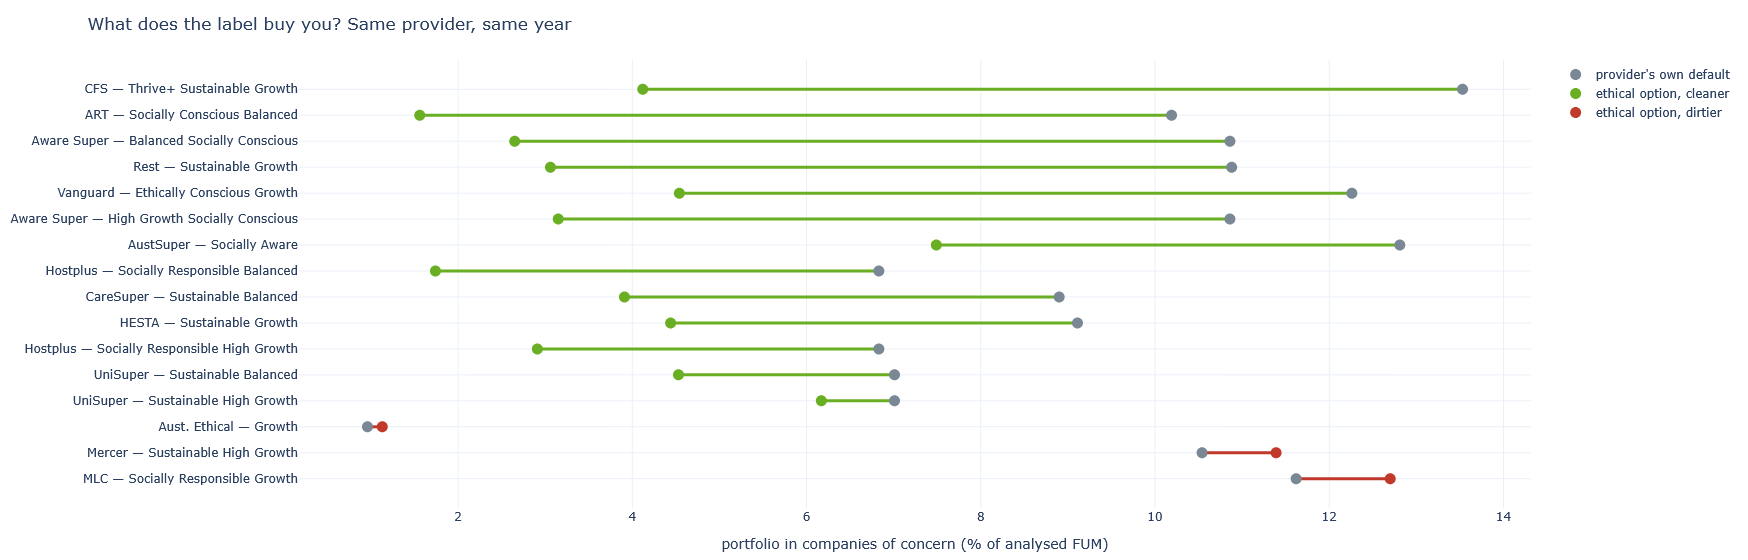

In [4]:
pairs = el.provider_pairs(df)
print(f"{len(pairs)} ethical options, {pairs['fund'].nunique()} providers")
print(f"ethical option cleaner than its own default: {(pairs['gap'] < 0).sum()}")
print(f"ethical option DIRTIER than its own default: {(pairs['gap'] > 0).sum()}")
print(f"median gap: {pairs['gap'].median():+.2f} percentage points\n")
print(pairs[pairs["gap"] > 0].round(2).to_string(index=False))
el.fig_pairs(pairs).show()

Most of the time the label buys a great deal: a median improvement of about
five percentage points of the portfolio. But three ethical options hold **more**
companies of concern than their own provider's default, and they are three very
different cases.

* **MLC Socially Responsible Growth** and **Mercer Sustainable High Growth** sit
  about a percentage point above their defaults. Mercer is the fund ASIC first
  took to court over sustainability claims, in 2024.
* **Australian Ethical Growth** sits 0.17 points above a default that is itself
  an ethical product and the cleanest option in the panel. Two near-zero numbers
  that differ mainly because the growth option holds more equities.

A single ranking cannot distinguish those cases. That is a first hint that the
label is not one thing.

> **Core exercise 2.1** — Compute the range of `total` for ethical options and
> for defaults separately. Do the two ranges overlap? How many of the fifteen
> defaults are cleaner than MLC Socially Responsible Growth?
>
> **Stretch exercise 2.2** — The gap is in percentage points of the portfolio.
> Recompute it as a *ratio* (ethical divided by default). Which options move up
> or down the ranking, and which measure would you show a member?

---
## 3. Which categories does the label separate?

A label can be strong on some categories and silent on others. For each
category, ask: across every pairing of one ethical option with one default, how
often is the ethical option the cleaner of the two?

<details>
<summary><b>Maths: the AUC as a head-to-head win rate</b> (click to expand)</summary>

Let $E$ be the set of ethical options and $D$ the set of defaults, with
$|E| = n_1$ and $|D| = n_0$. For a category with exposure $x$,

$$\mathrm{AUC} = \frac{1}{n_1 n_0} \sum_{i \in E} \sum_{j \in D}
\Big[\mathbf{1}(x_i < x_j) + \tfrac{1}{2}\,\mathbf{1}(x_i = x_j)\Big].$$

This is the area under the ROC curve of the rule "lower exposure means ethical",
and it equals the Mann–Whitney $U$ statistic divided by $n_1 n_0$. It is $1$ when
every ethical option beats every default, $0.5$ when the label carries no
information about the category, and below $0.5$ when ethical options are
systematically *worse*.

It is computed from ranks, so it is unaffected by the units of $x$ and by
outliers — useful when one category is measured in single percentage points and
another in tenths.

</details>

         dimension    kind   auc  default_mean  labelled_mean  ratio  rule_errors  want_avoided_pct
       Social harm  sector 0.958         1.107          0.061 18.265            1               NaN
      Fossil fuels  sector 0.877         5.137          1.129  4.551            3              69.0
Environmental harm   mixed 0.854         2.130          0.640  3.328            4              85.0
           Weapons  sector 0.846         0.755          0.226  3.338            5               NaN
      Human rights conduct 0.579         2.331          2.142  1.088           11              87.0
    Animal cruelty   mixed 0.542         1.220          1.254  0.973           11               NaN


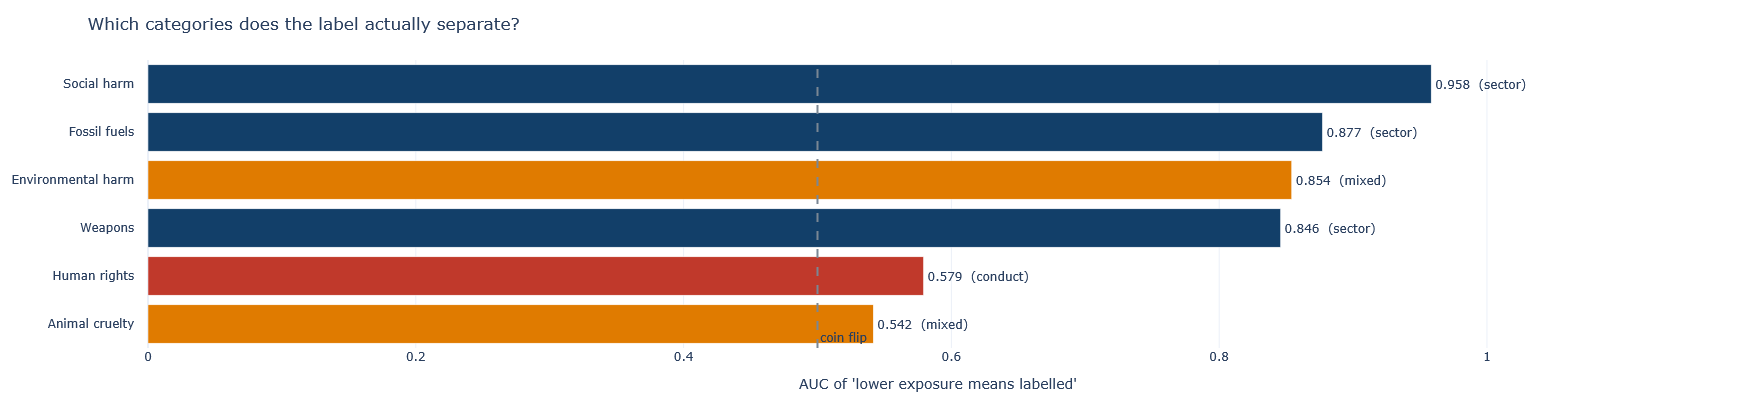

In [5]:
sep = el.dimension_separation(df)
print(sep[["dimension", "kind", "auc", "default_mean", "labelled_mean", "ratio",
           "rule_errors", "want_avoided_pct"]].round(3).to_string(index=False))
el.fig_separation(sep).show()

The `kind` column is the source's own distinction.

* **Sector** categories are binary revenue tests: a company either earns revenue
  above a threshold in tobacco, gambling, fossil fuels or weapons, or it does not.
  Cheap to screen, easy to check.
* **Conduct** categories are judgements about behaviour, assessed from
  controversy research. Human rights is the pure case.
* **Mixed** categories contain a bit of both.

The label separates the sector categories strongly and **human rights barely at
all**. On animal cruelty the ethical options are, on average, slightly *worse*
than the defaults. The last column is the share of Australians who say they want
each issue avoided: human rights comes first, at 87%.

`rule_errors` is how many of the thirty-one options the best one-line rule on
that category gets wrong. One threshold on social harm reproduces the label
with a **single** error. Compare that with the total:

In [6]:
t, e = el.best_threshold_rule(df["total"], y)
print(f"best rule on total exposure: ethical if total < {t:.2f}%  ->  {e} errors")
t, e = el.best_threshold_rule(df["social_harm"], y)
miss = df.loc[(df["social_harm"] < t).to_numpy() != y.astype(bool), "name"].tolist()
print(f"best rule on social harm:    ethical if social harm < {t:.2f}%  ->  {e} error: {miss}")

best rule on total exposure: ethical if total < 6.50%  ->  4 errors
best rule on social harm:    ethical if social harm < 0.67%  ->  1 error: ['Australian Ethical — MySuper Balanced']


The label tracks one specific sector screen more closely than it tracks overall
cleanliness. Everything that follows tests that claim without using the label.

> **Core exercise 3.1** — Explain in two sentences why a sector screen is easier
> to deliver, *and to verify*, than a conduct screen. Who produces the data each
> one needs?
>
> **Stretch exercise 3.2** — Find the best rule that uses **two** categories
> joined by *and*. Does any pair reproduce the label perfectly? Is the second
> category doing real work, or fitting a single option?

---
## 4. A product's fingerprint

From here on, each option is a point in six dimensions: its exposure in each
category. Two deliberate exclusions:

* **the label**, which is what we are testing;
* **the total**, which is a function of the six and would double-count.

Distance-based methods are only as good as the units they are fed. Look at the
spread of each category first.

In [7]:
spread = df[el.DIMS].agg(["std", "min", "max"]).T
spread.index = [el.DIM_LABELS[d] for d in spread.index]
spread.round(2)

,std,min,max
Fossil fuels,2.82,0.01,8.45
Human rights,0.97,0.43,4.62
Environmental harm,1.22,0.00,3.77
Social harm,0.59,0.00,1.66
Animal cruelty,0.70,0.00,3.50
Weapons,0.43,0.00,1.26


Fossil fuels varies over roughly eight percentage points; weapons over little
more than one. On raw units, fossil fuels would decide every distance and the
other five categories would be decoration.

Standardising gives every category the same spread. That is a **choice**, not
housekeeping: it asserts that a one-standard-deviation move in weapons exposure
is as meaningful as a one-standard-deviation move in fossil fuels. Section 9
shows how much the answer depends on it.

<details>
<summary><b>Maths: why units decide distances</b> (click to expand)</summary>

For options $i$ and $j$ with exposure vectors $x_i, x_j \in \mathbb{R}^6$,

$$d(i,j) = \sqrt{\sum_{c=1}^{6} (x_{i,c} - x_{j,c})^2 }.$$

Each category enters in the square of its own units, so its expected
contribution scales with its variance $\sigma_c^2$. Standardising replaces
$x_{i,c}$ with $z_{i,c} = (x_{i,c} - \mu_c)/\sigma_c$. Min–max scaling divides by
the range instead, and robust scaling by the interquartile range. Each implies a
different view of which differences matter. Lab 7c covers this in detail.

</details>

---
## 5. Interactive: cluster the products without the label

The map below places the options on their first two principal components,
computed once from standardised data, so **the map never moves**. Only the
colours change: they show the clusters found by whichever method, scaling and
number of clusters you choose. Circles are ethical options and crosses are
defaults — information the algorithm never sees.

Before you touch anything: at $k = 2$, how many options do you expect to land
on the "wrong" side?

In [8]:
def playground(k=2, scaling="standard", method="kmeans"):
    Z = el.scale(df, scaling)
    lab = el.partition(Z, method, k)
    ag = el.agreement(y, lab)
    print(f"k = {k}, {scaling} scaling, {method}:  ARI {ag['ari']:.3f}   NMI {ag['nmi']:.3f}")
    el.fig_pca_map(df, lab, title=f"{method}, k = {k}, {scaling} scaling").show()

if HAS_WIDGETS:
    widgets.interact(playground,
                     k=widgets.IntSlider(value=2, min=2, max=6, description="k"),
                     scaling=widgets.Dropdown(options=el.SCALINGS, value="standard"),
                     method=widgets.Dropdown(options=el.METHODS, value="kmeans"))
else:
    K, SCALING, METHOD = 2, "standard", "kmeans"      # FALLBACK: edit these
    playground(K, SCALING, METHOD)

interactive(children=(IntSlider(value=2, description='k', max=6, min=2), Dropdown(description='scaling', optio…

The axes have a meaning worth knowing. **PC1** loads positively on every
category: it is a general harm factor, and on its own it explains about 62% of
the variance. **PC2** contrasts human rights and animal welfare with the rest.
It is, almost exactly, the axis the label does not control.

> **Core exercise 5.1** — At $k = 2$ with standard scaling, which ethical options
> land with the defaults, and which default lands with the ethical options?
>
> **Core exercise 5.2** — Switch the method to `average` and leave everything
> else alone. What happens to the clusters, and to the ARI? Hold your
> explanation for Section 9.

---
## 6. Scoring a partition against a label

The algorithm produced a partition without the label. Now bring the label back
and ask how well the two agree. Because cluster numbers are arbitrary — "cluster
0" means nothing — we need a score that does not care how the clusters are
numbered.

<details>
<summary><b>Maths: the adjusted Rand index</b> (click to expand)</summary>

Consider every pair of options. A pair *agrees* if both partitions put the two
options together, or both put them apart. The **Rand index** is the share of
agreeing pairs. It is inflated by chance, so Hubert and Arabie (1985) adjusted
it. With a contingency table $n_{ij}$ between label class $i$ and cluster $j$,
row sums $a_i$, column sums $b_j$ and $n$ options,

$$\mathrm{ARI} = \frac{\sum_{ij}\binom{n_{ij}}{2} - \Big[\sum_i \binom{a_i}{2}\sum_j \binom{b_j}{2}\Big]\Big/\binom{n}{2}}
{\tfrac12\Big[\sum_i \binom{a_i}{2} + \sum_j \binom{b_j}{2}\Big] - \Big[\sum_i \binom{a_i}{2}\sum_j \binom{b_j}{2}\Big]\Big/\binom{n}{2}}.$$

It is $1$ for identical partitions, about $0$ for chance agreement, and can be
negative. **Normalised mutual information** asks instead how much knowing the
cluster tells you about the label, on a $0$ to $1$ scale. Neither is an
accuracy, and neither needs the clusters to be matched to classes first.

</details>

In [9]:
Z = el.scale(df, "standard")
lab2 = el.partition(Z, "kmeans", 2)
ag = el.agreement(y, lab2, df)

print(f"ARI {ag['ari']:.3f}   NMI {ag['nmi']:.3f}   agreement {ag['agreement_rate']:.1%}\n")
print(ag["table"], "\n")
print("ethical options in the high-harm cluster:", ag["labelled_in_high"])
print("defaults in the low-harm cluster:         ", ag["default_in_low"])

ARI 0.535   NMI 0.465   agreement 87.1%

                 high-harm cluster  low-harm cluster
                                                    
Ethical option                   3                13
MySuper default                 14                 1 

ethical options in the high-harm cluster: ['AustralianSuper — Socially Aware', 'Mercer Super — Sustainable High Growth', 'MLC — Socially Responsible Growth']
defaults in the low-harm cluster:          ['Australian Ethical — MySuper Balanced']


An ARI of about 0.54: substantial agreement, far from perfect. But the headline
number hides the shape of the disagreement, and the shape is the finding.

* **Three false positives.** AustralianSuper Socially Aware, Mercer Sustainable
  High Growth and MLC Socially Responsible Growth carry the label and sit with
  the defaults.
* **One false negative.** Australian Ethical's default sits with the ethical
  options.

The failure is almost entirely one-directional. *Labelled does not imply clean.*
*Clean implies labelled* — once you allow the label to live at the level of the
provider as well as the option. That asymmetry is worth more to a member than the
ARI, and it is the shape a regulator should care about: a threshold test targets
false positives and leaves false negatives alone.

---
## 7. Three kinds of "sustainable"

Two clusters forced a yes-or-no answer. Allow three.

k = 2: silhouette 0.448
k = 3: silhouette 0.465
         options  ethical  mean_total  defaults
cluster                                        
1             13       12        2.98         1
2              2        2        8.78         0
0             16        2       10.44        14

the small cluster: ['Mercer Super — Sustainable High Growth', 'UniSuper — Sustainable High Growth']


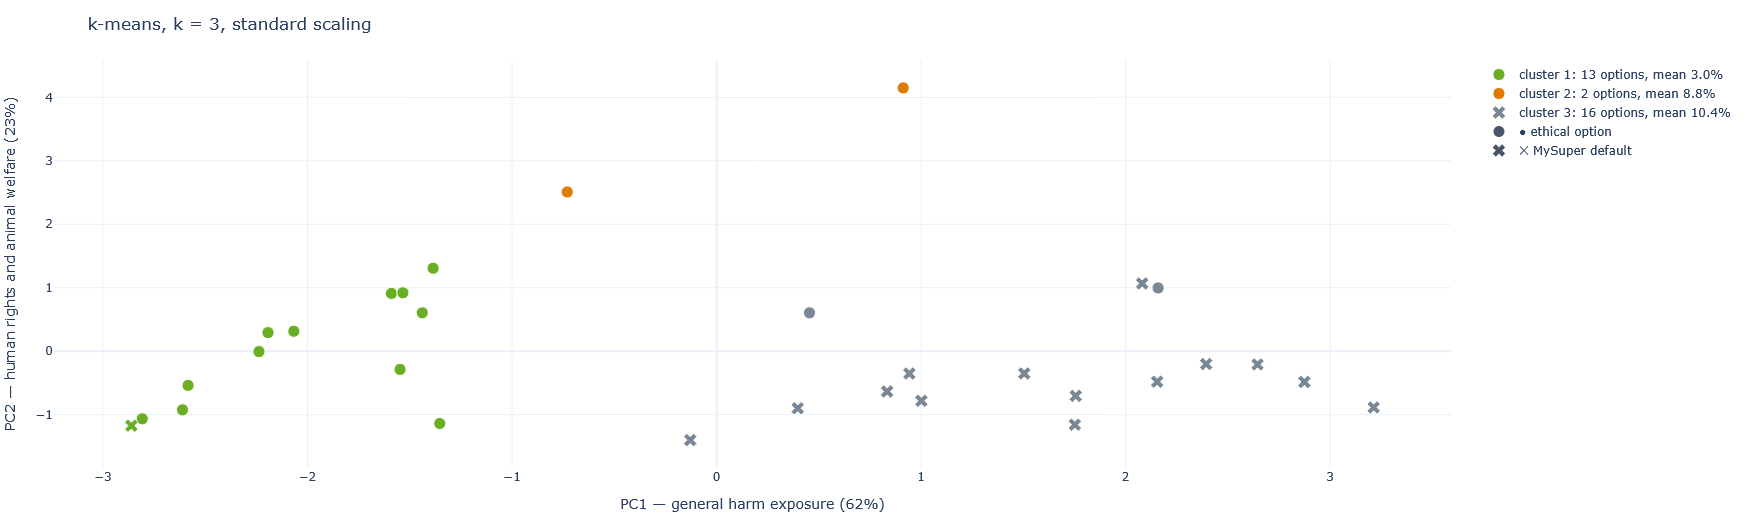

In [10]:
lab3 = el.partition(Z, "kmeans", 3)
for k_, lab_ in [(2, lab2), (3, lab3)]:
    print(f"k = {k_}: silhouette {silhouette_score(Z, lab_):.3f}")

groups = (pd.DataFrame({"cluster": lab3, "ethical": y, "total": df["total"], "name": df["name"]})
          .groupby("cluster")
          .agg(options=("name", "size"), ethical=("ethical", "sum"),
               mean_total=("total", "mean"))
          .sort_values("mean_total"))
groups["defaults"] = groups["options"] - groups["ethical"]
print(groups.round(2))
small = groups.index[groups["options"] <= 3]
for c in small:
    print(f"\nthe small cluster: {df.loc[lab3 == c, 'name'].tolist()}")
el.fig_pca_map(df, lab3, title="k-means, k = 3, standard scaling").show()

The silhouette marginally prefers three clusters to two — a rare case of the
geometric criterion and the substantive reading agreeing. The three groups read
as a taxonomy of what "sustainable" means in practice.

1. **A broad screen** — twelve ethical options and Australian Ethical's default,
   with a mean total of about 3%. The label does what a member would assume.
2. **Fossil-screened, socially exposed** — Mercer and UniSuper Sustainable High
   Growth. Low fossil exposure, and the highest human-rights and animal-welfare
   exposures in the panel. Not weak products: products that screened one axis
   thoroughly and left another untouched.
3. **Indistinguishable from the default** — the other fourteen defaults, plus
   AustralianSuper Socially Aware and MLC Socially Responsible Growth.

Group 2 is exactly the pattern Section 3 predicted from the category table: a
sector screen applied, a conduct dimension left alone.

> **Core exercise 7.1** — Re-run the $k = 3$ partition for ten different random
> seeds (`el.partition(Z, "kmeans", 3, seed=s)`). Does the small cluster always
> contain the same two options?

---
## 8. Hierarchy: two readings of one tree

Hierarchical methods do not choose a number of clusters; they produce a whole
tree of nested groupings. There are two ways to read one.

* **Agglomerative**, bottom up: start with every option on its own and merge the
  closest pair, again and again. It answers *which products are twins?*
* **Divisive**, top down: start with the whole market and split it on its
  sharpest fault line, again and again. It answers *what divides the market?*

For a label audit, the divisive reading is the natural one: if the first split of
the market is not the thing the label claims to control, the label is not the
market's organising fact.

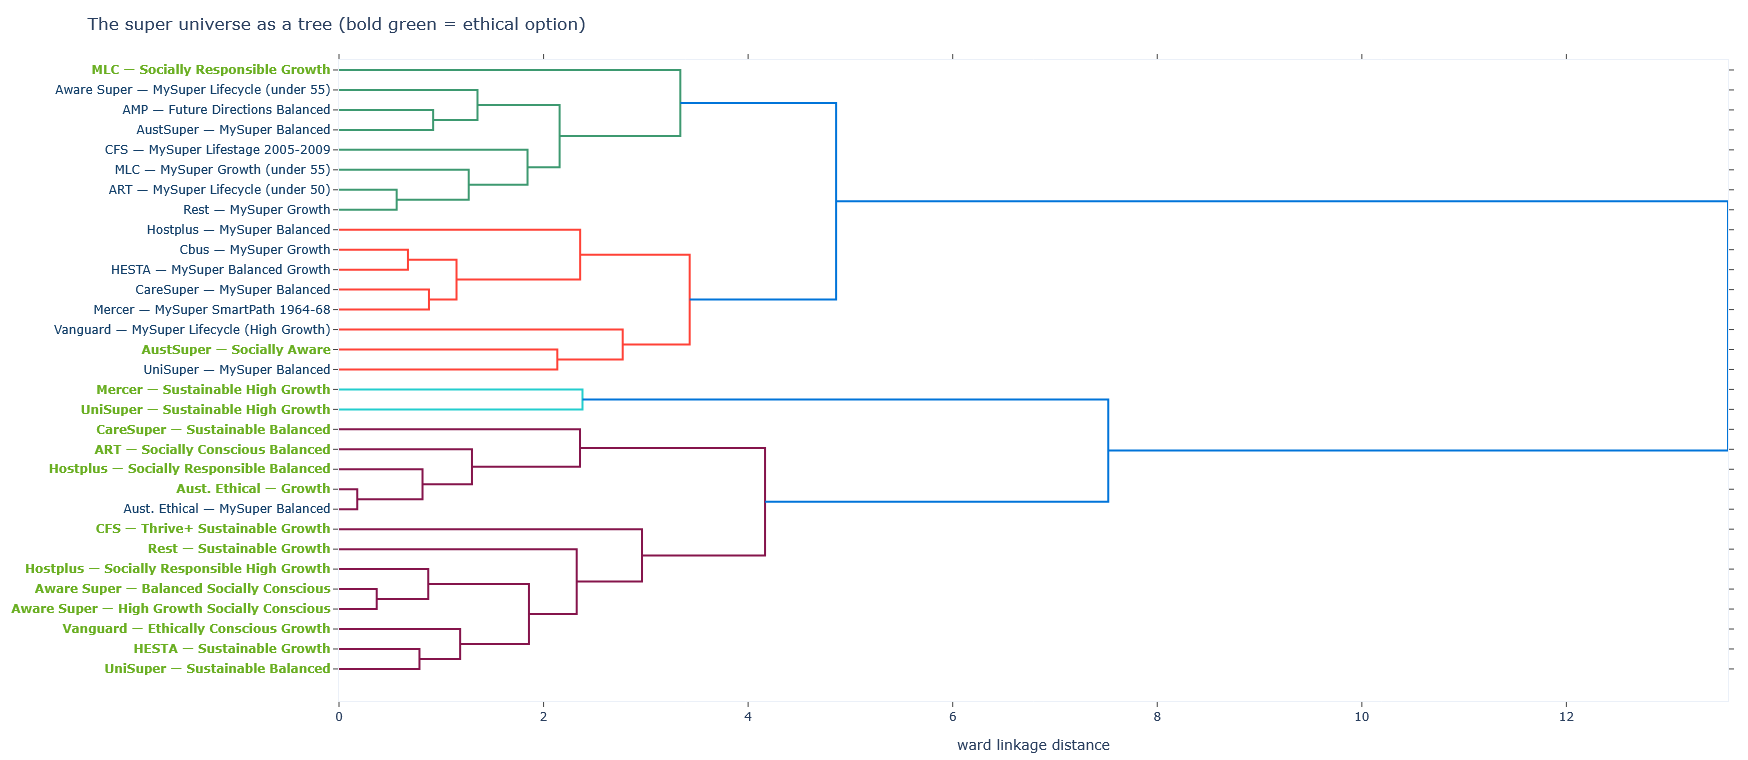

In [11]:
el.fig_dendrogram(df, method="ward").show()

In [12]:
# Bottom up: which options merge first?
L = linkage(Z, method="ward")
n, members = len(df), {i: [i] for i in range(len(df))}
for step, (a, b, dist, _) in enumerate(L[:5]):
    a, b = int(a), int(b)
    members[n + step] = members[a] + members[b]
    print(f"merge {step + 1} at distance {dist:.3f}:  "
          f"{[df['name'][i] for i in members[a]]}  +  {[df['name'][i] for i in members[b]]}")

merge 1 at distance 0.178:  ['Australian Ethical — Growth']  +  ['Australian Ethical — MySuper Balanced']
merge 2 at distance 0.369:  ['Aware Super — Balanced Socially Conscious']  +  ['Aware Super — High Growth Socially Conscious']
merge 3 at distance 0.564:  ['Australian Retirement Trust — MySuper Lifecycle (under 50)']  +  ['Rest — MySuper Growth']
merge 4 at distance 0.674:  ['Cbus — MySuper Growth']  +  ['HESTA — MySuper Balanced Growth']
merge 5 at distance 0.787:  ['HESTA — Sustainable Growth']  +  ['UniSuper — Sustainable Balanced']


The closest pair in the entire panel is Australian Ethical Growth and Australian
Ethical's own default: an ethical option and a MySuper option that are, in what
they hold, near twins. The next merge is also a same-provider pair. Providers run
families of portfolios, and the family resemblance is stronger than the label.

Now read the tree from the top. `BisectingKMeans` is a divisive method: it splits
the whole panel in two, then splits the larger half again.

In [13]:
first = el.first_bisection(df)
print("first split, sizes", first.attrs["sizes"])
print(first.round(3).to_string(index=False), "\n")

# second split: let the divisive algorithm take its next step
three = BisectingKMeans(n_clusters=3, n_init=10, random_state=0).fit(Z).labels_
small = np.bincount(three).argmin()
print("the second split isolates:", df.loc[three == small, "name"].tolist())

# is that robust? repeat with twenty different seeds
sizes = [tuple(sorted(int(v) for v in np.bincount(
            BisectingKMeans(n_clusters=3, n_init=10, random_state=s).fit(Z).labels_)))
         for s in range(20)]
print("cluster sizes across 20 seeds:", pd.Series(sizes).value_counts().to_dict())

first split, sizes [14, 17]
         dimension    kind  separates_the_halves
      Fossil fuels  sector                 0.987
           Weapons  sector                 0.979
Environmental harm   mixed                 0.966
       Social harm  sector                 0.929
      Human rights conduct                 0.765
    Animal cruelty   mixed                 0.756 

the second split isolates: ['Mercer Super — Sustainable High Growth']
cluster sizes across 20 seeds: {(1, 14, 16): 17, (2, 14, 15): 3}


Read top down, the market divides first on **fossil fuels** — one of the label's
strong dimensions, so here the market and the label broadly agree.

The next split, inside the high-exposure half, **isolates Mercer Sustainable
High Growth on its own**. It holds the highest human-rights and animal-cruelty
exposures in the whole panel, and it is the same product Section 10 will find has
no peers at all. MLC Socially Responsible Growth stays with the defaults: it looks
like one.

Look at the robustness check. In a few seeds the split lands somewhere else,
pairing Mercer with MLC. That is not a second answer; it is a **local optimum**,
with a larger within-cluster sum of squares. Bisecting $k$-means runs $k$-means at
every step, and inherits its dependence on where it starts.

> **Core exercise 8.1** — Re-draw the dendrogram with `method="average"` and then
> `method="complete"`. Which reading of the market changes most?
>
> **Core exercise 8.2** — Find a seed that pairs Mercer with MLC. Compute the
> within-cluster sum of squares of both three-cluster solutions and confirm which
> one the algorithm should prefer.

---
## 9. The audit verdict is a methodological choice

Everything so far used one pipeline: standard scaling and $k$-means. There are
other defensible pipelines. Run sixteen — four clustering methods by four
scalings — and score each against the label.

          standard  minmax  robust  none
kmeans        0.54    0.64    0.28  0.64
ward          0.64    0.64    0.36  0.54
complete      0.44    0.64    0.00  0.44
average       0.00    0.64    0.00  0.54

ARI across 16 pipelines: 0.00 to 0.64


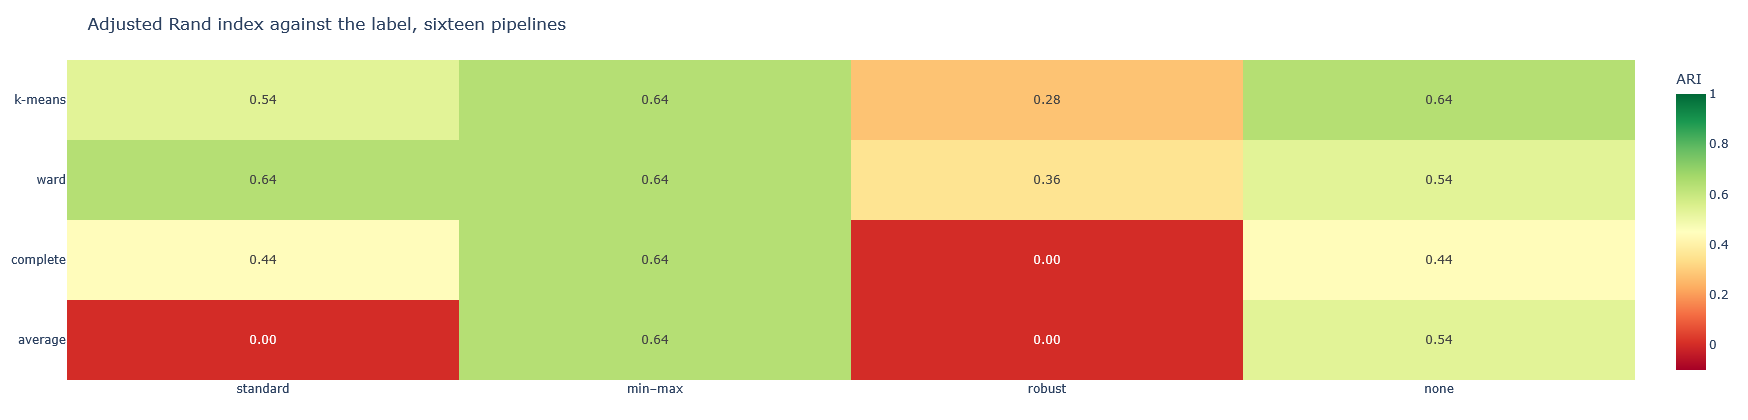

In [14]:
grid = el.sensitivity_grid(df)
print(grid.round(2))
print(f"\nARI across {grid.size} pipelines: {grid.values.min():.2f} to {grid.values.max():.2f}")
el.fig_grid(grid).show()

The same thirty-one options and the same $k = 2$ produce an ARI anywhere from
zero to about 0.64. Average linkage on standardised or robust-scaled data chains
the points into one long group plus a couple of stragglers, and reports that the
label is pure noise. Min–max scaling gives the highest agreement for every method.

**Do not shop for a pipeline.** If you choose the scaler after seeing the ARI, you
have written a press release, not an audit. Pre-specify the pipeline, give the
reason, and publish the full grid beside the headline number.

The more useful question is what survives *across* pipelines:

In [15]:
freq = el.outlier_frequency(df)
print(f"How often each ethical option sits with the defaults, out of {grid.size} pipelines:\n")
print(freq[freq > 0].to_string())

How often each ethical option sits with the defaults, out of 16 pipelines:

name
MLC — Socially Responsible Growth                            16
AustralianSuper — Socially Aware                             12
Mercer Super — Sustainable High Growth                        5
CareSuper — Sustainable Balanced                              5
Rest — Sustainable Growth                                     4
Aware Super — Balanced Socially Conscious                     3
Australian Retirement Trust — Socially Conscious Balanced     3
Australian Ethical — Growth                                   3
HESTA — Sustainable Growth                                    3
Colonial First State — Thrive+ Sustainable Growth             3
Aware Super — High Growth Socially Conscious                  3
Hostplus — Socially Responsible High Growth                   3
Hostplus — Socially Responsible Balanced                      3
UniSuper — Sustainable Balanced                               3
UniSuper — Sustainable 

**MLC Socially Responsible Growth sits with the defaults in all sixteen
pipelines.** AustralianSuper Socially Aware does in twelve. (The long tail of 3s
is the three chaining pipelines, where almost every option collapses into one
group; they say nothing about any particular product.) Mercer Sustainable
High Growth, which looked like an outlier at $k = 2$, does in only five — because
it is not default-like. It is something else, and Section 10 shows what.

The identity of the most robust outlier is far more stable than the ARI itself.
That is the finding worth reporting.

> **Core exercise 9.1** — Add `single` linkage to the grid. Predict the result
> before you run it, using what you saw average linkage do.
>
> **Stretch exercise 9.2** — Leave one provider out at a time (both its default and
> its ethical options), recompute the standard $k$-means ARI, and plot the
> fifteen results. Which provider moves the verdict most, and why?

---
## 10. Density: the product with no peers

$k$-means and hierarchical methods must put every option in some group.
Density-based clustering does not. DBSCAN (Ester and colleagues, 1996) groups
points that have enough close neighbours, and labels the rest **noise**. For an
audit, noise is the most interesting output there is: it means *no comparable
product exists*.

Sweep the neighbourhood radius and watch who is left without peers.

In [16]:
sweep = el.dbscan_sweep(df)
print(sweep[["eps", "clusters", "noise", "noise_labelled"]].to_string(index=False), "\n")
for r in sweep.itertuples():
    if r.noise <= 5:
        print(f"eps = {r.eps}: {r.noise_members}")

 eps  clusters  noise  noise_labelled
1.00         2     15               7
1.25         2     11               7
1.50         2      7               5
1.75         2      5               4
2.00         2      1               1
2.25         2      1               1 

eps = 1.75: ['AustralianSuper — Socially Aware', 'CareSuper — Sustainable Balanced', 'Mercer Super — Sustainable High Growth', 'MLC — Socially Responsible Growth', 'Vanguard Super — MySuper Lifecycle (High Growth)']
eps = 2.0: ['Mercer Super — Sustainable High Growth']
eps = 2.25: ['Mercer Super — Sustainable High Growth']


At the widest radius, one option still has no peers: **Mercer Sustainable High
Growth** — the sustainable option of the first fund ASIC took to court over
sustainability claims. At a slightly tighter radius the noise set is five
options, four of them ethical.

Notice that there are **two different kinds of anomaly** here. MLC Socially
Responsible Growth *looks like a default* — robustly, in every pipeline. Mercer
Sustainable High Growth *looks like nothing else*. A supervisor would want to ask
each of them a different question.

Be careful how much weight you put on the Mercer result. With thirty-one
options it is a coincidence until it replicates. But it is the right *kind* of
output: a screening tool should hand a supervisor a shortlist, not a verdict.

> **Core exercise 10.1** — Change `min_samples` to 2 and then 4. Does Mercer
> remain the last option standing?

---
## 11. Soft assignment: a negative result worth having

A Gaussian mixture gives each option a *probability* of belonging to each
cluster, rather than a hard assignment. The question it can answer is sharp: are
the off-diagonal options from Section 6 genuinely **between** two groups, or
firmly in the "wrong" one?

In [17]:
watch = ["AustralianSuper — Socially Aware", "Mercer Super — Sustainable High Growth",
         "MLC — Socially Responsible Growth", "Australian Ethical — MySuper Balanced"]
idx = [df.index[df["name"] == w][0] for w in watch]
for cov in ["spherical", "diag", "tied"]:
    gm = GaussianMixture(n_components=2, covariance_type=cov, n_init=50,
                         random_state=42, reg_covar=1e-4).fit(Z)
    p = gm.predict_proba(Z).max(axis=1)
    print(f"{cov:9s}  lowest membership {p.min():.3f}   "
          + "   ".join(f"{w.split(' — ')[0]}: {p[i]:.3f}" for w, i in zip(watch, idx)))

spherical  lowest membership 0.988   AustralianSuper: 1.000   Mercer Super: 1.000   MLC: 1.000   Australian Ethical: 1.000
diag       lowest membership 0.946   AustralianSuper: 1.000   Mercer Super: 0.991   MLC: 1.000   Australian Ethical: 1.000
tied       lowest membership 0.988   AustralianSuper: 0.988   Mercer Super: 0.991   MLC: 1.000   Australian Ethical: 1.000


Every option's strongest membership is at least 0.94, and the four off-diagonal
options are all at 0.98 or higher. **There is no ambiguous middle.** The three
ethical options that sit with the defaults are not borderline cases the model
could not decide about; they sit squarely with the defaults.

A negative result, and a useful one: it rules out the comfortable reading that
these are simply hard-to-classify products. (A full-covariance mixture is not
identified with thirty-one points in six dimensions, which is why it is not
used.)

---
## 12. The lower bound: does looking harder find more?

Every exposure in this panel is measured on the **disclosed** part of the
portfolio only, and disclosure coverage runs from about half to nearly all of an
option's value. If undisclosed holdings resemble disclosed ones, coverage does
not matter. If they do not, options that disclose less will look cleaner partly
*because* they disclose less.

That is the missing-not-at-random problem from Lab 7b, now at the level of a
product. The panel lets us test one implication of it.

           group  n  spearman  p_value  median_disclosure
     all options 31     0.183    0.325             71.360
 ethical options 16     0.541    0.030             78.795
MySuper defaults 15     0.475    0.074             68.070


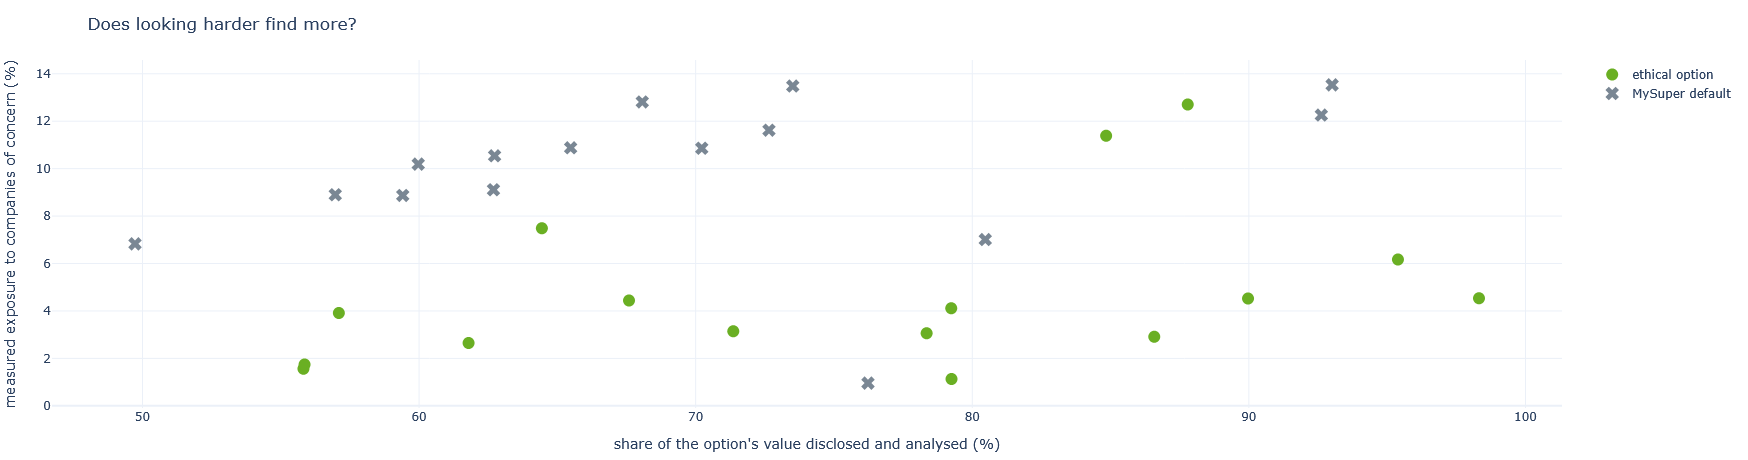

In [18]:
print(el.disclosure_check(df).round(3).to_string(index=False))
el.fig_disclosure(df).show()

Across all thirty-one options there is no clear relationship. **Among the ethical
options, those that disclose more show more exposure** — a rank correlation of
about 0.54 with $p$ near 0.03, from sixteen options.

Three honest caveats before you quote that.

1. **Two subgroups were tested.** One $p$ of 0.03 among two tests is weaker
   evidence than it looks.
2. **Asset mix is a plausible confounder.** Growth options hold more listed
   equity, which must be disclosed by name, *and* more companies of concern. The
   correlation could run through asset mix rather than through concealment.
3. **Correlation cannot establish direction.** Nothing here shows that anyone
   chose to disclose less in order to look cleaner.

What the result does establish is that **measured exposure is a lower bound, and
not an equally loose one for every option**. A comparison between an option
disclosing 56% of its value and one disclosing 98% is not like for like.

> **Stretch exercise 12.1** — Build a crude asset-mix control: flag ethical
> options whose name contains "Growth". Remove each group's mean from both
> disclosure and exposure, then recompute the correlation. Does the association
> survive the control, weaken, or vanish?

---
## 13. Exercises

### Core

1. **Where does the label live?** Recode Australian Ethical's MySuper option as
   `"Ethical"` and re-run Sections 2 and 6. What happens to the false negative, to
   the ARI and to the within-provider comparison? Which coding is right for a
   member choosing an *option*, and which for a regulator labelling a *provider*?

2. **One number or six?** Cluster on `total` alone (a one-dimensional feature)
   and score it against the label. What is gained, and what is lost, compared with
   the six-category fingerprint? Use Group 2 from Section 7 in your answer.

3. **Your pre-registered pipeline.** Choose one scaling and one method *before*
   looking at Section 9 again. Write two sentences justifying the choice on
   economic grounds, then report its ARI and its false positives.

4. **A threshold regime.** Suppose a label required social harm below 0.5% *and*
   fossil fuels below 1%. Which of the sixteen ethical options would keep their
   label? Which default would qualify for one?

### Stretch

5. **Shape, not level.** Replace Euclidean distance with cosine distance
   (normalise each option's six-vector to unit length before clustering). This
   compares the *profile* of exposure rather than its size. Which options change
   group, and what does that say about the difference between a "small" and a
   "different" portfolio?

6. **Stability as evidence.** Bootstrap the panel (resample options with
   replacement, 500 times), recompute the standard $k$-means ARI each time, and
   report a 90% interval. Is the ARI distinguishable from zero? From 0.8?

7. **Beyond this panel.** Mindful Money publishes the same analysis for
   New Zealand KiwiSaver funds. Sketch how you would run this audit on a second
   market, and what would have to be true for the results to be comparable.

---

### What to take away

* The label **narrows** the expectation and does not determine it: ethical
  options run from about 1% to nearly 13% exposure, and three sit above their own
  provider's default.
* The label screens **sectors, not conduct**. One social-harm threshold nearly
  reproduces it; human rights barely separates at all.
* Clustering without the label recovers it only partly, and the failure runs
  almost entirely one way: labelled does not imply clean.
* The ARI depends on the pipeline. **The identity of the most robust outlier
  does not.** Report the grid, not the best cell.
* Density methods can say "no peers". For an audit, that is the most valuable
  thing they say.
* Measured exposure is a lower bound, and the bound is looser for some products
  than others.

### Where this goes next

Lab **9b** turns the audit around: instead of inferring what products hold, you
will **build** products from explicit screening rules on the same equity
universe, and discover how different "sustainable" portfolios can be when the
rules are all reasonable. **Week 10** then takes these features and clusters into
the optimiser, as constraints, and asks what they cost.